<a href="https://colab.research.google.com/github/MariamKSharkawy/ML-projects/blob/main/CC_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/My Drive/colab_data/creditcard[1].csv')

In [ ]:
#df=pd.read_csv('/content/sample_data/creditcard[1].csv')

In [ ]:
#data has no nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# FRAUD CLASS IS ONLY 0.17% OF THE WHOLE DATA

In [ ]:
#see data imbalance
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
#check for duplicates
df.duplicated().sum()

np.int64(1081)

In [ ]:
#drop duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

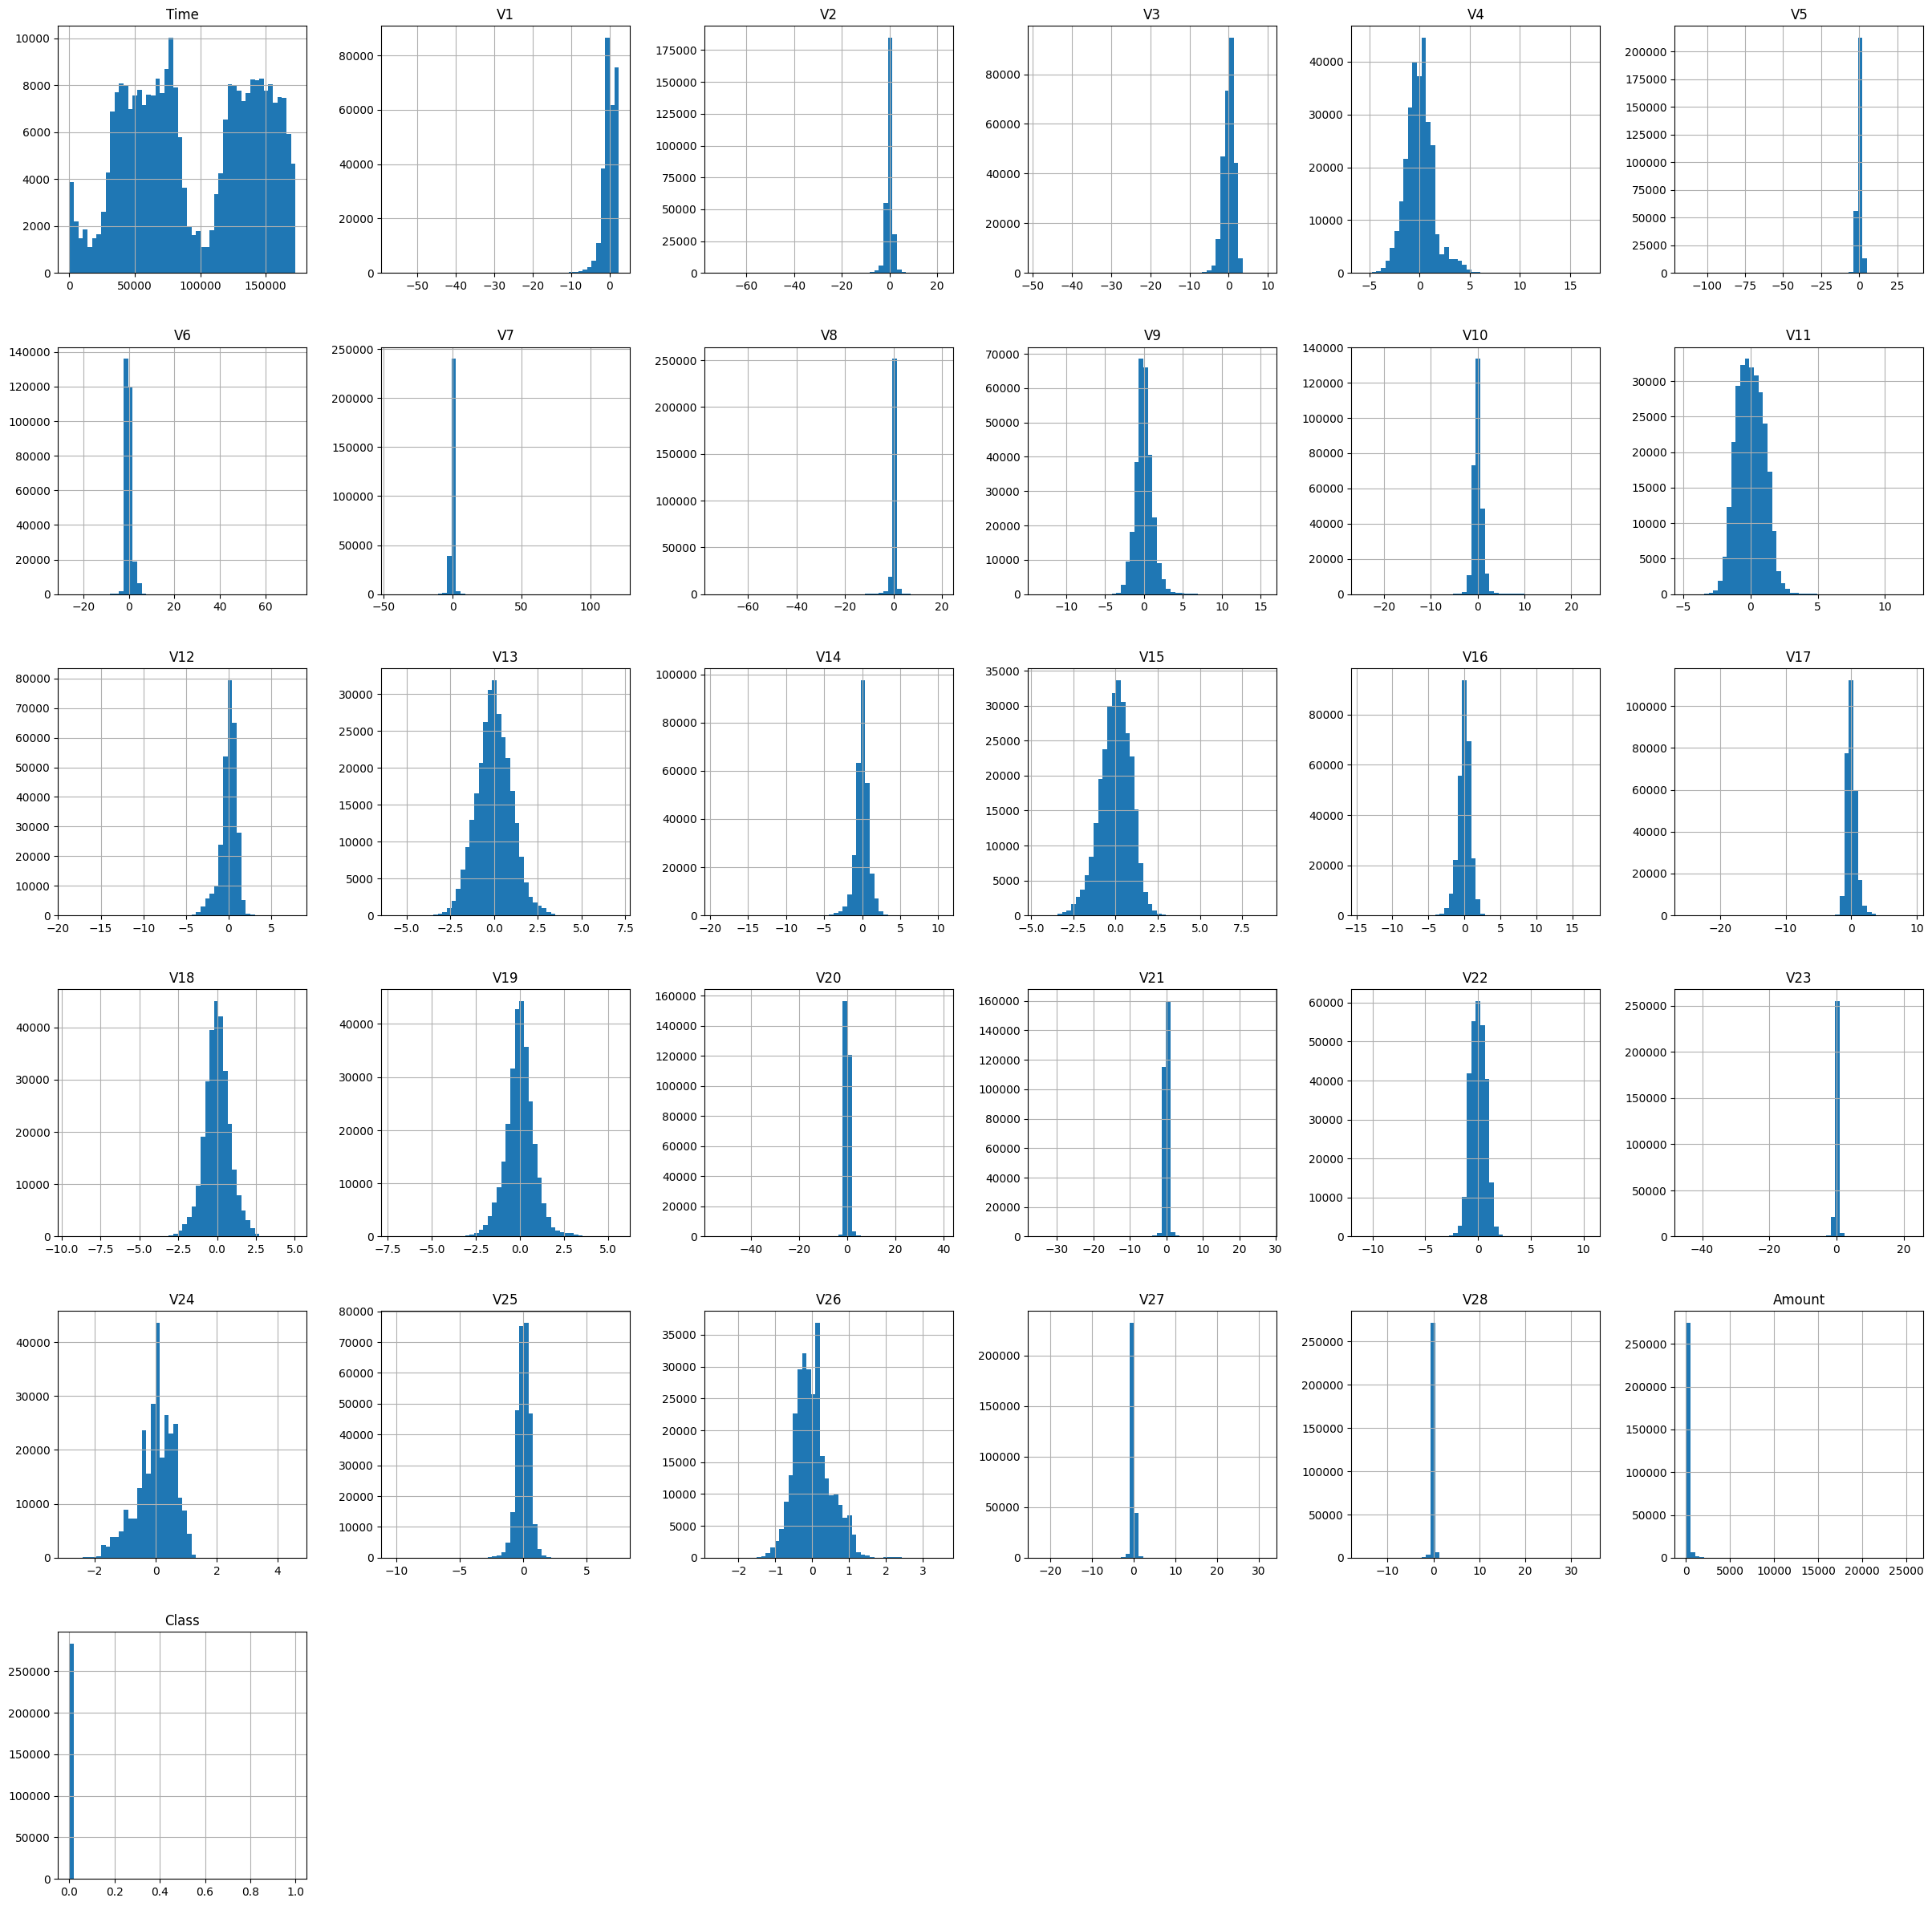

In [ ]:
#check the representation of different columns
df.hist(bins=50, figsize=(30,30))

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x7d8d1e8f9690>,
 'caps': [<matplotlib.lines.Line2D at 0x7d8d1e8fa790>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d8d243db010>],
 'medians': [<matplotlib.lines.Line2D at 0x7d8d1e8fb890>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d8d1e903dd0>],
 'means': []}

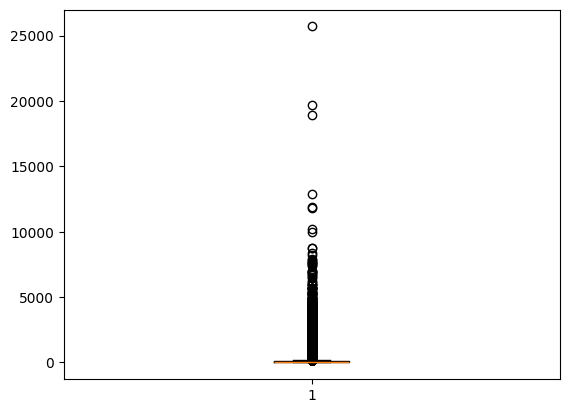

In [ ]:
#take a closer look at the outliers of the amount column it has many outliers
plt.boxplot(df['Amount'])

In [ ]:
#scaling with standard scaler will not be ideal AS it has a lot of outliers
from sklearn.preprocessing import RobustScaler
robust_scale = RobustScaler()
df['scaled_amount'] = robust_scale.fit_transform(df[['Amount']]) #use robust scaler because the data is not normally distributed and has many outliers

In [ ]:
df['scaled_amount'].describe()

,scaled_amount
count,283726.000000
mean,0.924387
std,3.482123
min,-0.305938
25%,-0.228063
50%,0.000000
75%,0.771937
max,356.962314


In [ ]:
from sklearn.preprocessing import MinMaxScaler
min_max_scale = MinMaxScaler()
df['scaled_time'] = min_max_scale.fit_transform(df[['Time']]) # put all the time between 0 and 1
df.drop(['Time','Amount'], axis=1, inplace=True)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.774718,0.000000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.268530,0.000000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.959811,0.000006
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.411487,0.000006
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.667362,0.000012


In [ ]:
df=df.sample(frac=1,random_state=2) #frac=1 means to keep all the rows but shuffle them

In [ ]:
#split the data into train, val and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class', axis=1), df['Class'], test_size=0.2, random_state=1)
#split the train data into train and validate
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
231085,-9.981540,8.762508,-5.871641,-3.159649,-1.876741,-2.290867,0.126184,1.547721,6.416225,11.119020,...,0.376026,0.302607,-0.057523,1.396582,-0.063795,1.212343,-0.589916,0,-0.296482,0.848465
25121,-0.128884,0.013790,-0.057724,-2.472085,2.004543,3.247855,-0.383882,0.841669,-1.557362,0.251669,...,-0.236560,-0.037883,0.985028,-0.308991,-0.496754,0.137384,0.141749,0,-0.195383,0.193996
208184,2.258110,-1.040285,-0.888370,-1.143064,-0.615509,0.181451,-1.204080,0.124858,0.411084,0.743378,...,-0.321052,0.291592,-0.375015,-0.364257,-0.406848,0.004435,-0.047659,0,-0.292032,0.792901
78577,-0.087776,0.887197,2.022645,2.941103,-0.199224,0.002194,-0.038813,0.097040,-1.021977,0.783001,...,0.580356,0.209783,0.386446,-1.323578,-0.029481,0.271787,0.252055,0,-0.080935,0.333320
195814,-0.141806,0.126412,-0.494090,-0.554668,1.989893,0.499769,1.030752,-0.162739,0.478109,-0.737857,...,1.475147,0.248508,-1.478438,-0.606293,-0.155188,-0.236529,-0.436140,0,-0.054930,0.759462


In [ ]:
X_train.shape,X_test.shape,X_val.shape,y_train.shape,y_test.shape,y_val.shape

((181584, 30), (56746, 30), (45396, 30), (181584,), (56746,), (45396,))

In [ ]:
#check to see the data has class with 1 and 0 values are distributed in the train, test, split
y_train.value_counts(),y_test.value_counts(),y_val.value_counts()

(Class
 0    181312
 1       272
 Name: count, dtype: int64,
 Class
 0    56632
 1      114
 Name: count, dtype: int64,
 Class
 0    45309
 1       87
 Name: count, dtype: int64)

In [ ]:
#the data is highly imbalanced so smooth that
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


#to stabilize the model numbers when training, stop the randomization---> achieve determinsim

In [ ]:
import os, random
import numpy as np
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(seed)
np.random.seed(seed)


# time to test, try different models
Logistic regression model


In [ ]:
#logistic regression model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(penalty='l2',       # L2 regularization (default)
    C=0.1,              # You can try smaller values like 0.1, 0.01 for stronger effect
    solver='lbfgs', # Use 'lbfgs' for LARGE datasets
    random_state=42
)
model.fit(X_train,y_train)
model.score(X_train,y_train)

0.9992730637060534

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_val,model.predict(X_val),target_names=['Not Fraud','Fraud']))

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     45309
       Fraud       0.92      0.55      0.69        87

    accuracy                           1.00     45396
   macro avg       0.96      0.78      0.85     45396
weighted avg       1.00      1.00      1.00     45396



In [ ]:
print("pred:0 pred:1")
print(confusion_matrix(y_val,model.predict(X_val)))

pred:0 pred:1
[[45305     4]
 [   39    48]]


In [ ]:
print(classification_report(y_test,model.predict(X_test),target_names=['Not Fraud','Fraud']))

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56632
       Fraud       0.87      0.54      0.67       114

    accuracy                           1.00     56746
   macro avg       0.94      0.77      0.83     56746
weighted avg       1.00      1.00      1.00     56746



pred:0 pred:1


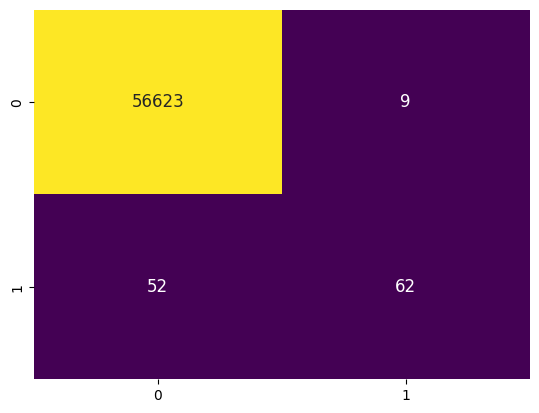

In [ ]:
#check the confusion matrix and a heatmap representation
print("pred:0 pred:1")
conf_matx=confusion_matrix(y_test,model.predict(X_test))
sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis")
plt.show()

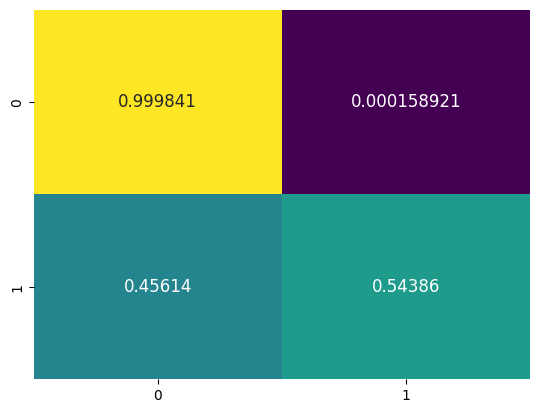

In [ ]:
#visualize confusion matrix normalized
conf_matx=confusion_matrix(y_test,model.predict(X_test),normalize='true')
sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis")
plt.show()

#SVM model

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the SVM model (you can start with linear kernel or try 'rbf')
model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train, y_train)

# Evaluate
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Detailed classification report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


Train Accuracy: 0.9979899110053749
Test Accuracy: 0.9967574807034857
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56632
           1       0.33      0.61      0.43       114

    accuracy                           1.00     56746
   macro avg       0.67      0.80      0.71     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

prec, rec, thresh = precision_recall_curve(y_test, y_pred)
f1 = 2 * (prec * rec) / (prec + rec + 1e-8)

best_idx = np.argmax(f1)
print(f"Best F1 threshold: {thresh[best_idx]:.2f}")
print(f"Best F1-score: {f1[best_idx]:.2f}")


Best F1 threshold: 1.00
Best F1-score: 0.43


#Random Forest Classifier model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)
model.score(X_train,y_train)

1.0

In [ ]:
model.score(X_val,y_val)

0.9993391488236849

In [ ]:
model.score(X_test,y_test)

0.9993303492757198

In [ ]:
#check the classification report as accuracy alone is not enough
print(classification_report(y_test,model.predict(X_test),target_names=['Not Fraud','Fraud']))

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56632
       Fraud       0.94      0.71      0.81       114

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746



pred:0 pred:1


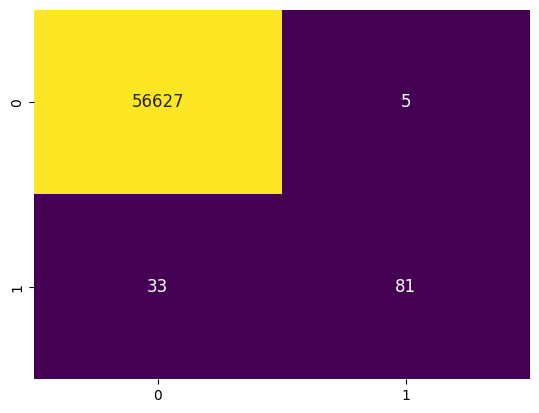

In [ ]:
print("pred:0 pred:1")
conf_matx=confusion_matrix(y_test,model.predict(X_test))
sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis")
plt.show()

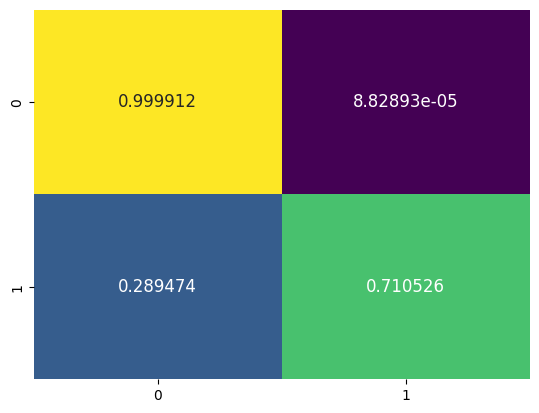

In [ ]:
#visualize confusion matrix normalized
conf_matx=confusion_matrix(y_test,model.predict(X_test),normalize='true')
sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis")
plt.show()

#Neural network model


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout
from keras.models import Sequential

tf.random.set_seed(seed) #make sure to turn off randomness for TF as well
model = keras.Sequential()
model.add(Dense(64, activation='relu', input_shape=X_train.shape[1:]))
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,337 (16.94 KB)

 Trainable params: 4,337 (16.94 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

In [ ]:
history=model.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_val, y_val),
          class_weight={0: 1, 1: 10}, callbacks=[early_stop])

Epoch 1/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9691 - loss: 0.1186 - val_accuracy: 0.9995 - val_loss: 0.0039
Epoch 2/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9990 - loss: 0.0176 - val_accuracy: 0.9995 - val_loss: 0.0037
Epoch 3/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9990 - loss: 0.0151 - val_accuracy: 0.9995 - val_loss: 0.0037
Epoch 4/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9991 - loss: 0.0126 - val_accuracy: 0.9995 - val_loss: 0.0037
Epoch 5/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9990 - loss: 0.0114 - val_accuracy: 0.9995 - val_loss: 0.0036
Epoch 6/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9990 - loss: 0.0100 - val_accuracy: 0.9995 - val_loss: 0.0038
Epoch 7/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9989 - loss: 0.0093 - val_accuracy: 0.9995 - val_loss: 0.0040


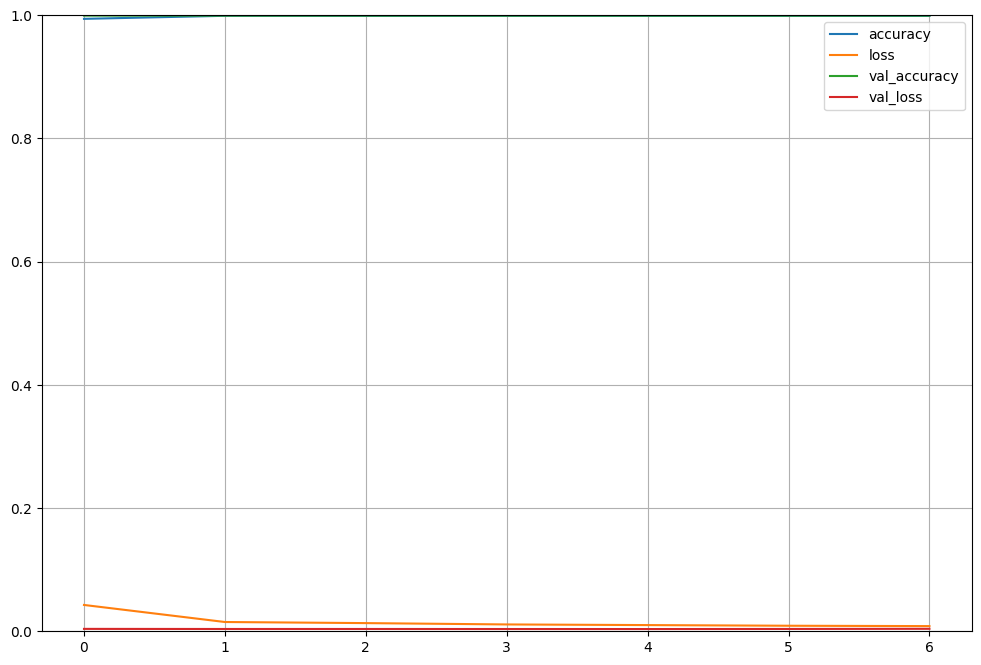

1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9995 - loss: 0.0038
Loss     :  0.003616231493651867
accuracy :  0.9994733333587646


In [ ]:
pd.DataFrame(history.history).plot(figsize=(12, 8))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

# Evaluate the model
model_evaluate = model.evaluate(X_val, y_val)
print("Loss     : ",model_evaluate[0])
print("accuracy : ",model_evaluate[1])

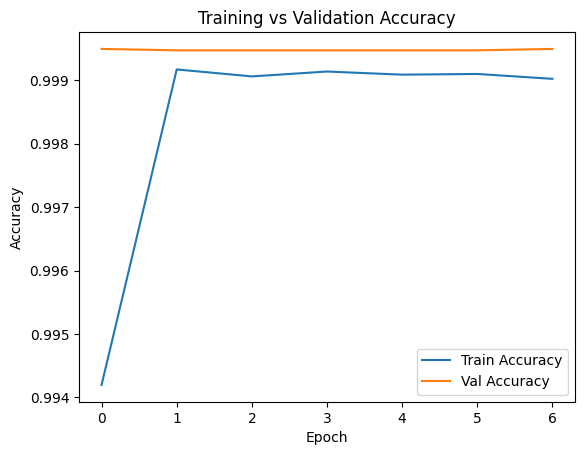

In [ ]:
#plot training/validation accuracy and loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
model.predict(X_test)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


array([[1.2384927e-05],
       [2.1732527e-04],
       [2.9944758e-07],
       ...,
       [3.1695198e-04],
       [5.8483580e-05],
       [7.2983188e-05]], dtype=float32)

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32").tolist()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Classification report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56873
           1       0.78      0.78      0.78        89

    accuracy                           1.00     56962
   macro avg       0.89      0.89      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix : 

[[56854    19]
 [   20    69]]


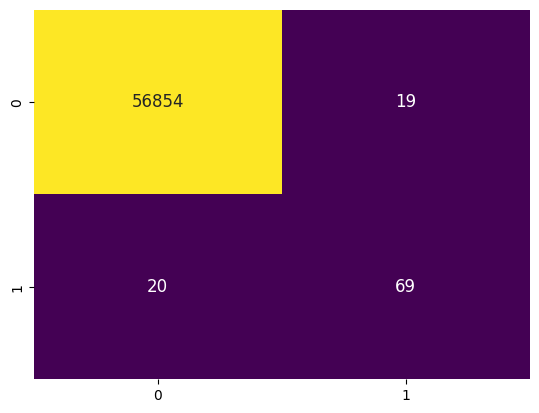

Normalized confusion matrix : 

[[1.   0.  ]
 [0.22 0.78]]


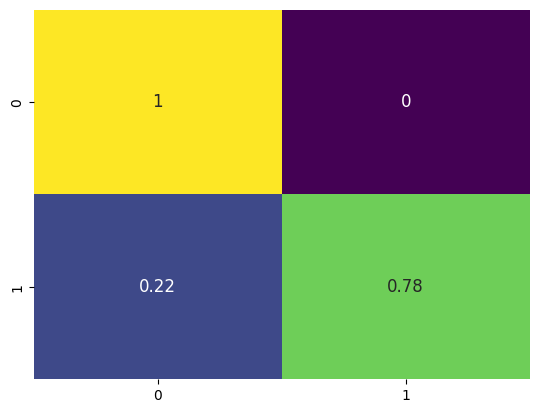

In [ ]:
# Confusion Matrix
class_names = ["0", "1"]
# Compute classification report
print("Classification report : \n",classification_report(y_test, y_pred, target_names = class_names))

# Function to draw confusion matrix
def draw_confusion_matrix(true, preds, normalize=None):
  # Compute confusion matrix
    conf_matx = confusion_matrix(true, preds, normalize = normalize)
    conf_matx = np.round(conf_matx, 2)
    print(conf_matx)

  # plt.subplots(figsize=(14,8))
    sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis")
    plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred, "true")

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score,accuracy_score, confusion_matrix, classification_report

In [ ]:
model=KMeans(n_clusters=2,random_state=42)
y_pred=model.fit_predict(X_train)
print('inertia',model.inertia_)
print('silhouette score:' ,silhouette_score(X_train,y_pred))
print('accuracy score:',accuracy_score(y_train,y_pred))

inertia 7545495.761999537
silhouette score: 0.9783153079224207
accuracy score: 0.9984910564807472


In [ ]:
import gc

del model, y_pred
gc.collect()

36

In [ ]:
model=AgglomerativeClustering(n_clusters=2)
y_pred=model.fit_predict(X_train)
print('silhouette score:' ,silhouette_score(X_train,y_pred))
print('accuracy score:',accuracy_score(y_train,y_pred))